<center><h1><b>INVARIANT MASS FIT AND $D_0$ COUNT</b></h1></center>
In this file we will upload the dataframes of the found candidate couples (decaying in the $D_0$) and we will fit the invariant mass, finding the number of $D_0$.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import norm
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import mean_squared_error

plt.rcParams['font.size'] = 15

In [2]:
files = ! ls /home/shared/Final_Chunk*.pkl              # ritorna la lista dei file che matchano il pattern
bucket = []
for item in files:
    bucket.append( pd.read_pickle(item) )
df = pd.concat(bucket, ignore_index=True)
print(f"The dataframe of the candidates has", len(df), "rows and", len(df.columns), "columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:.2f} MB in RAM memory.")
df.head()

The dataframe of the candidates has 3490378 rows and 5 columns.
It occupies 133.15 MB in RAM memory.


,mass,dcaXY,pt,cos_pointing,decay_length
0,1.821499,-0.000005,0.775502,0.923646,0.007234
1,1.832552,-0.000004,1.448730,0.962763,0.004363
2,1.842711,-0.000010,2.671746,0.991940,0.027235
3,2.077747,-0.000007,2.760309,0.991226,0.020889
4,2.127117,-0.000036,2.288202,0.997269,0.014921


## INITIAL VARIABLES
Let's choose the binning and the width for the fit. This choice will influence the whole notebook.

In [3]:
m_d0 = 1.86484

N_BINS = 400
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
STEP = (MAX_MASS-MIN_MASS)/N_BINS

## PLOT OF MASS VALUES

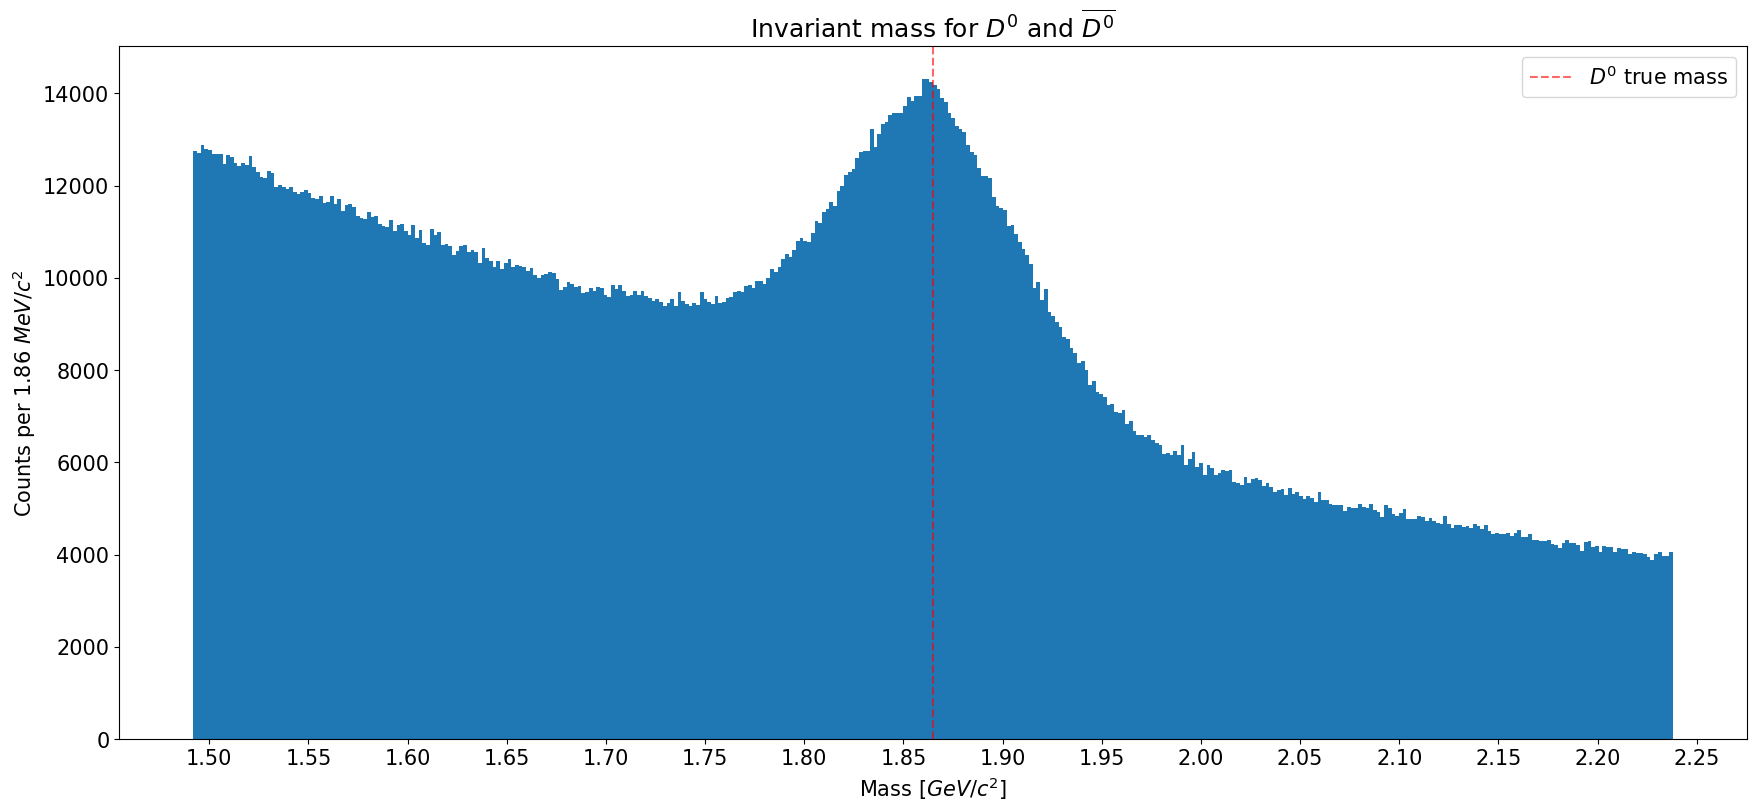

In [4]:
fig, ax = plt.subplots(figsize=(21,9))
counts, edges, graph = plt.hist(df["mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS), align="mid")
plt.xlabel(r"Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {STEP*1000:.2f} $MeV/c^2$")
plt.xticks(np.arange(1.50,2.26, 0.05))
plt.axvline(x=m_d0, color="red", alpha=0.6, linestyle='--', label=r'$D^0$ true mass')
plt.legend()
plt.title(r"Invariant mass for $D^0$ and $\overline{D^0}$")
plt.show()

## NORMALIZATION
We will normalize the blue area to 1. In this way we can avoid possible problems arising from the bad choices of initial parameters for the fit, leading to unsuccesful fit results. Later we will remember this normalization to go back and obtain the counting of $D_0$s.

In [5]:
# area calculation
area = np.sum( counts*STEP )
print(f"The blue area amounts to: {area:.2f}")

The blue area amounts to: 6509.00


(The actual normalization will be done inside the code for the fit)

## INVARIANT MASS FIT
Let's try three different background functions, always starting from a gaussian for the peak: parabolic, linear and exponential.
\begin{equation}
f(x) = N \cdot \frac{1}{\sqrt{2\pi}\,\sigma} \,
e^{-\frac{(x-\mu)^2}{2\sigma^2}}
+ \text{pedestal} + Bx + A x^2
\end{equation}

\begin{equation}
f(x) = N \cdot \frac{1}{\sqrt{2\pi}\,\sigma} \,
e^{-\frac{(x-\mu)^2}{2\sigma^2}}
+ \text{pedestal} + \rho x
\end{equation}

\begin{equation}
f(x) = N \cdot \frac{1}{\sqrt{2\pi}\,\sigma} \,
e^{-\tfrac{(x-\mu)^2}{2\sigma^2}}
+ \text{pedestal} + A \, e^{-(x - \text{off})
}
\end{equation}

The $pedestal$ variable is for the vertical shift.

In [6]:
# FIT FUNCTIONS
def parabolic_model( x, pedestal, N, mu, sig, B, A ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + B*x + A*x**2 )
def linear_model( x, pedestal, N, mu, sig, rho ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig )  + pedestal + x * rho )
def exponential_model( x, pedestal, N, mu, sig, off, A ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + A*np.exp( off - x ) )

# # let's define some initial guesses for some variables
# ped_guess = [22_000, 4_000]
# N_guess = [5_000, 600]
# A_guess = [2_000, 15_000]

/tmp/ipykernel_137775/2787237256.py:7: RuntimeWarning: overflow encountered in exp
  return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + A*np.exp( off - x ) )
/tmp/ipykernel_137775/2787237256.py:7: RuntimeWarning: overflow encountered in exp
  return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + A*np.exp( off - x ) )


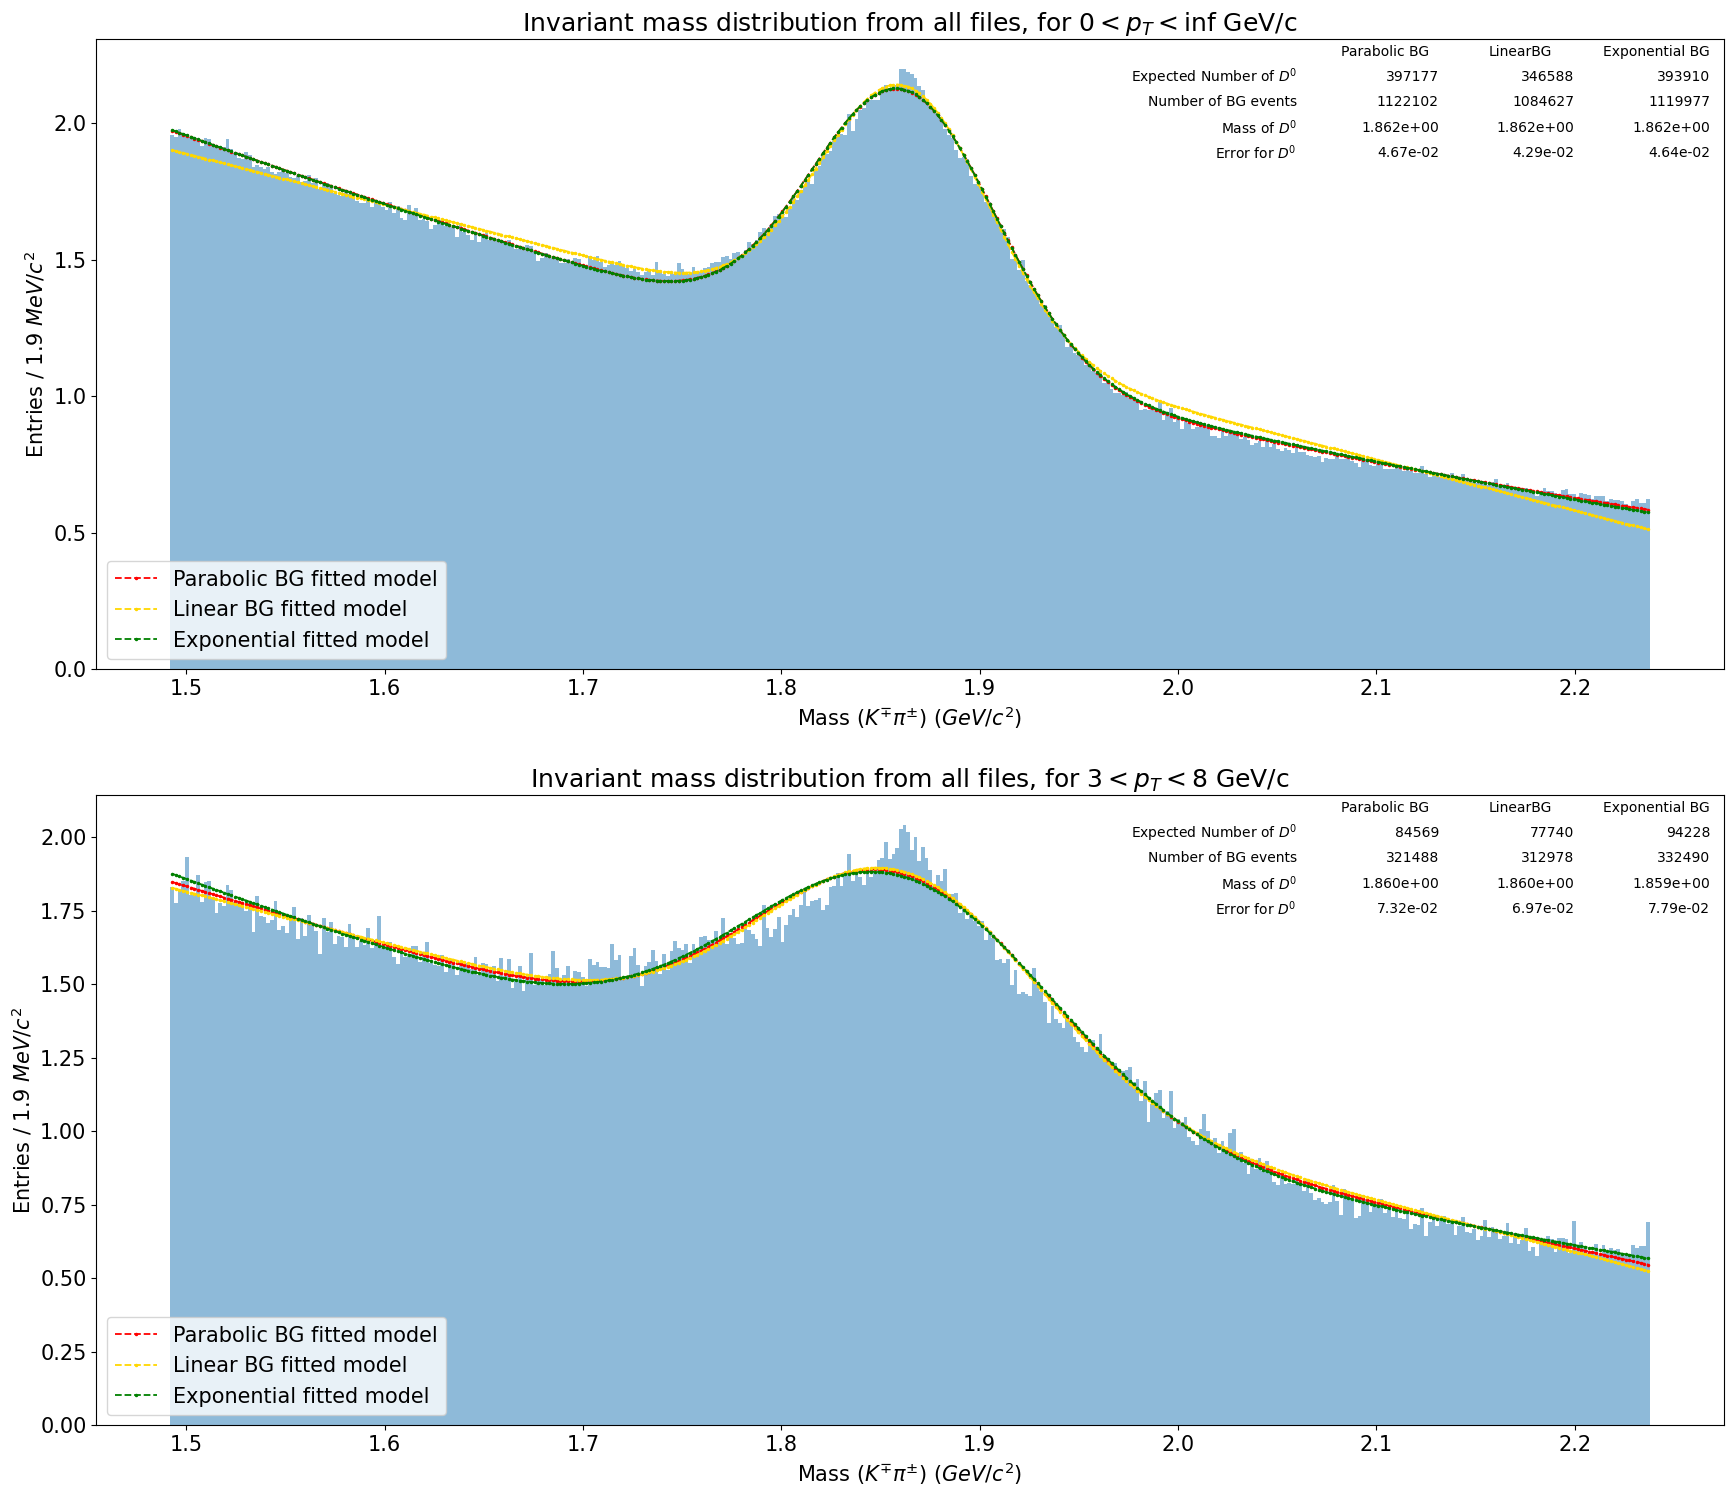

,Background,Pt_interval,Amplitude,Pedestal,Mu,Sigma,Slope,B,A,Offset,D0_counts,RMSE,chi2,BG_events,StatSignif,S/B
0,Parabolic,"[0, inf]",0.1141,8.0611,1.8619,0.0467,NaN,-5.5549,0.9891,NaN,397177.3053,0.0209,850.0006,1.1221e+06,322.2297,0.3540
1,Linear,"[0, inf]",0.0996,4.6897,1.8620,0.0429,-1.8675,NaN,NaN,NaN,346587.5354,0.0360,3590.0614,1.0846e+06,289.7080,0.3195
2,Exponential,"[0, inf]",0.1132,-0.6941,1.8617,0.0464,NaN,NaN,NaN,1.8339,393910.0633,0.0219,1008.0106,1.1200e+06,320.1476,0.3517
3,Parabolic,"[3, 8]",0.1332,5.7269,1.8602,0.0732,NaN,-3.1658,0.3799,NaN,84569.0266,0.0449,722.5339,3.2149e+05,132.7144,0.2631
4,Linear,"[3, 8]",0.1225,4.4414,1.8603,0.0697,-1.7508,NaN,NaN,NaN,77740.0729,0.0455,796.0278,3.1298e+05,124.3692,0.2484
5,Exponential,"[3, 8]",0.1484,-0.6164,1.8595,0.0779,NaN,NaN,NaN,1.8133,94227.9819,0.0462,719.7377,3.3249e+05,144.2479,0.2834


In [7]:
from scipy.stats import norm
from scipy.integrate import quad  # to integrate

# facciamo due volte il fit, una generale su tutta la fascia di pt, e una concentrata nella fascia 3-8:
pt_extremes = [[0, np.inf], [3,8]]
times = len(pt_extremes)

# let's initialize some lists to later insert results
N_recap, pedestal_recap, mu_recap, sigma_recap, par1_recap, par2_recap, interval_recap = ([] for _ in range(7))
BKG_type, slope, all_Bs, all_As, all_offsets, all_taus, D0_counts =                      ([] for _ in range(7))
areas, rmse, chi2, BG_events, Z, S_over_B = ([] for _ in range(6))

fig, axs = plt.subplots( nrows = times, ncols = 1, figsize = ( 21, 9 * times ) )
# approximated graph
for i in range( times ) :

    # FILTERING IN ZONES OF INTEREST
    pt_lim = pt_extremes[ i ]
    ax = axs[ i ]
    mass = df[df["pt"].between(pt_lim[0], pt_lim[1])]["mass"]
    
    # HISTOGRAM AND NORMALIZATION OF COUNTS
    counts, edges = np.histogram(mass, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
    area = np.sum( counts*STEP )
    areas.append(area)
    counts = counts/area                        # normalization
    centers = ( edges[:-1] + edges[1:] ) / 2.   # centering the edges of the intervals
    ax.bar(centers, counts, width=STEP, align="center", alpha=0.5)
    
    # FIT WITH THE THREE BG MODELS
    parab_fit_res = curve_fit( f = parabolic_model, xdata = centers, ydata = counts, p0 = [ 4, 0.9, m_d0, 0.1/6., -2, 0.01 ] )
    parab_pars = parab_fit_res[0]
    lin_fit_res = curve_fit( f = linear_model, xdata = centers, ydata = counts, p0 = [ 4, 0.9, m_d0, 0.1/6., -2 ] )
    lin_pars = lin_fit_res[0]
    exp_fit_res = curve_fit( f = exponential_model, xdata = centers, ydata = counts, p0 = [ 4, 0.9, m_d0, 0.1/6., m_d0, -1 ] )
    exp_pars = exp_fit_res[0]

    # CALCULATE THE RMSE (errore quadratico medio) OF THE FOUND MODELS
    parab_rmse = np.sqrt( mean_squared_error( counts, parabolic_model(centers, *parab_pars) )   )
    lin_rmse = np.sqrt(   mean_squared_error( counts, linear_model(centers, *lin_pars)      )   )
    exp_rmse = np.sqrt(   mean_squared_error( counts, exponential_model(centers, *exp_pars) )   )

    # CALCULATE THE CHI-SQUARED USING POISSON ERRORS
    # as errors we use the poisson approximation: errors = sqrt(N)
    errors = np.sqrt(counts * area) / area    # dato che counts è normalizzato, calcolo la sigma originale e poi rinormalizzo
    parab_chi2 = np.sum( ( (counts - parabolic_model(centers, *parab_pars) ) / errors)**2)
    lin_chi2   = np.sum( ( (counts - linear_model(centers, *lin_pars) ) / errors)**2)
    exp_chi2   = np.sum( ( (counts - exponential_model(centers, *exp_pars) ) / errors)**2)

    
    # PLOT OF THE FITTED FUNCTIONS
    ax.plot( centers, parabolic_model(centers, *parab_pars),
        color='red', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Parabolic BG fitted model' )
    ax.plot( centers, linear_model( centers, *lin_pars ),
        color='gold', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Linear BG fitted model' )
    ax.plot( centers, exponential_model( centers, *exp_pars),
        color='green', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Exponential fitted model' )

    # EXTRACTING THE FOUND MASS VALUES AND ESTIMATING THE NUMBER OF D_0
    m_parab = parab_pars[2]           # found mass
    s_parab = parab_pars[3]           # found mass error
    K_parab = parab_pars[1]*( norm.cdf( m_parab + 3.*s_parab, loc = m_parab, scale = s_parab )
                          - norm.cdf( m_parab - 3.*s_parab, loc = m_parab, scale = s_parab ))/STEP   *areas[i]  # number of D_0 (multiplied for the area to remove normalization)
    m_lin = lin_pars[2]
    s_lin = lin_pars[3]
    K_lin = lin_pars[1]*( norm.cdf( m_lin + 3.*s_lin, loc = m_lin, scale = s_lin )
                          - norm.cdf( m_lin - 3.*s_lin, loc = m_lin, scale = s_lin ))/STEP    *areas[i]
    m_exp = exp_pars[2]
    s_exp = exp_pars[3]
    K_exp = exp_pars[1]*( norm.cdf( m_exp + 3.*s_exp, loc = m_exp, scale = s_exp )
                          - norm.cdf( m_exp - 3.*s_exp, loc = m_exp, scale = s_exp ) )/STEP    *areas[i]

    # ESTIMATING THE NUMBER OF BACKGROUND EVENTS FOR STATISTICAL SIGNIFICANCE (as the area of background function)
    int_parab = quad(parabolic_model, m_d0 - 3*s_parab, m_d0 + 3*s_parab, args=tuple(parab_pars))
    int_lin   = quad(linear_model, m_d0 - 3*s_lin, m_d0 + 3*s_lin, args=tuple(lin_pars))
    int_exp   = quad(exponential_model, m_d0 - 3*s_exp, m_d0 + 3*s_exp, args=tuple(exp_pars))
    bg_parab  = int_parab[0]/STEP*areas[i] - K_parab
    bg_lin    = int_lin[0]/STEP*areas[i] - K_lin
    bg_exp    = int_exp[0]/STEP*areas[i] - K_exp

    # STATISTICAL SIGNIFICANCE
    Z_parab = K_parab / np.sqrt(K_parab + bg_parab)
    Z_lin   = K_lin   / np.sqrt(K_lin   + bg_lin)
    Z_exp   = K_exp   / np.sqrt(K_exp   + bg_exp)
    S_over_B_parab = K_parab / bg_parab
    S_over_B_lin   = K_lin   / bg_lin
    S_over_B_exp   = K_exp   / bg_exp
 
    # ESTHETICS:
    ax.table( 
        cellText = [[f"{K_parab:.0f}", f"{K_lin:.0f}", f"{K_exp:.0f}"],[f"{bg_parab:.0f}", f"{bg_lin:.0f}", f"{bg_exp:.0f}"],
                    [ f"{m_parab:.3e}", f"{m_lin:.3e}", f"{m_exp:.3e}" ], [f"{s_parab:.2e}", f"{s_lin:.2e}", f"{s_exp:.2e}"] ],
        rowLabels = [ r'Expected Number of $D^0$', r'Number of BG events', r'Mass of $D^0$', r'Error for $D^0$'],
        colLabels = [ 'Parabolic BG', 'LinearBG', 'Exponential BG' ],
        # cellColours = [ [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ], [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ], [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ] ],
        # cellColours = [ [ 'red', 'blue' ], [ 'red', 'blue' ],[ 'red', 'blue' ] ],
        bbox = [ 0.75, 0.8, 0.25, 0.2 ],
        edges = 'open',
        rowLoc = 'right',
        )
    # ax.text( m_parab, hist.min() + 30 , r'Expected $K_S^0$: ' + f"{K_parab:.0f}", size = 25, c= 'red', horizontalalignment='center' )
    # ax.text( m_lin, hist.min() , r'Expected $K_S^0$: ' + f"{K_lin:.0f}", size = 25, c= 'blue', horizontalalignment='center' )
    # # ax.text( m_exp, exp_pars[0], r'Expected $K_S^0$: ' + f"{K_exp:.0f}", size = 25, c= 'blue' )    
    ax.set_title( r"Invariant mass distribution from all files, for " + str(pt_lim[0]) + r"$ < p_{T} <$" + str(pt_lim[1]) + r" GeV/c" )
    # to reset into linear scale, default histo for the function
    ax.set_yscale( 'linear' )
    ax.set_xlabel( r'Mass ($K^{\mp}\pi^{\pm}$) $(GeV/c^2)$')
    ax.set_ylabel( r"Entries / "+f"{STEP*1000.:.1f}"+r" $MeV/c^2$")
    ax.legend( loc = 'lower left' )

    # SAVING RESULTS in lists, then we will use a dataframe:
    N_recap.extend([parab_pars[1], lin_pars[1], exp_pars[1]])
    pedestal_recap.extend([parab_pars[0], lin_pars[0], exp_pars[0]])
    mu_recap.extend([parab_pars[2], lin_pars[2], exp_pars[2]])
    sigma_recap.extend([parab_pars[3], lin_pars[3], exp_pars[3]])
    BKG_type.extend(["Parabolic", "Linear", "Exponential"])
    slope.extend([None, lin_pars[4], None])
    all_Bs.extend([parab_pars[4], None, None])
    all_As.extend([parab_pars[5], None, None])
    # all_taus.extend([None, None, exp_pars[4]])
    all_offsets.extend([None, None, exp_pars[4]])
    D0_counts.extend([K_parab, K_lin, K_exp])
    rmse.extend([parab_rmse, lin_rmse, exp_rmse])
    chi2.extend([parab_chi2, lin_chi2, exp_chi2])
    BG_events.extend( [ bg_parab, bg_lin, bg_exp ] )
    Z.extend([Z_parab, Z_lin, Z_exp])                       # statistical significance
    S_over_B.extend([S_over_B_parab, S_over_B_lin, S_over_B_exp])

    #par1_recap.append()
    #par2_recap = []
    for tt in range (3):
        interval_recap.append(pt_lim)

pd.set_option("display.precision", 4)
recap = pd.DataFrame({
    "Background": BKG_type,
    "Pt_interval": interval_recap,
    "Amplitude": N_recap,
    "Pedestal": pedestal_recap,
    "Mu": mu_recap,
    "Sigma": sigma_recap,
    "Slope": slope,
    "B": all_Bs,
    "A": all_As,
    #"Tau": all_taus,
    "Offset": all_offsets,
    "D0_counts": D0_counts,
    "RMSE": rmse,
    "chi2": chi2,
    "BG_events": BG_events,
    "StatSignif": Z,
    "S/B": S_over_B
})
plt.show()

recap

In [8]:
print(f"The two blue areas are {areas[0]:.2f} and {areas[1]:.2f}.")

The two blue areas are 6509.00 and 1187.12.


## PLOT $D_0$ COUNTING

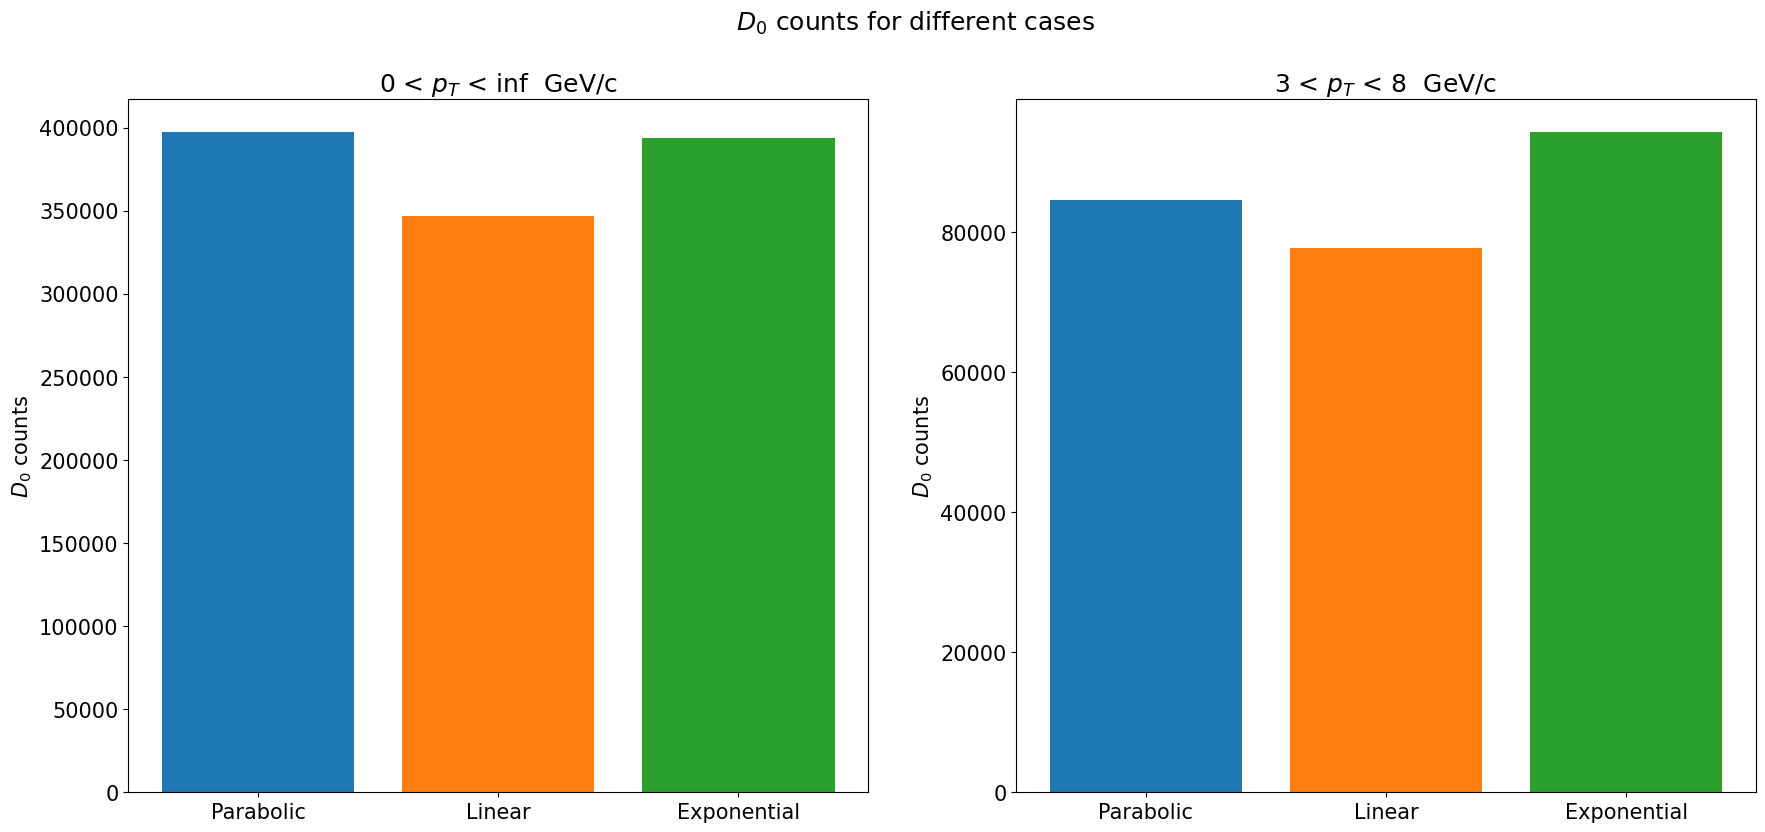

In [9]:
fig, axs = plt.subplots( nrows = 1, ncols = times, figsize = ( 21, 9 ) )
fig.suptitle(f"$D_0$ counts for different cases")
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# BARPLOT
axs[0].bar(["Parabolic", "Linear", "Exponential"], recap["D0_counts"].iloc[:3], color=colors)
axs[1].bar(["Parabolic", "Linear", "Exponential"], recap["D0_counts"].iloc[3:], color=colors)

# ESTETICHS
axs[0].set_ylabel(f"$D_0$ counts")
axs[1].set_ylabel(f"$D_0$ counts")
axs[0].set_title(f"{pt_extremes[0][0]} < $p_T$ < {pt_extremes[0][1]}  GeV/c" )
axs[1].set_title(f"{pt_extremes[1][0]} < $p_T$ < {pt_extremes[1][1]}  GeV/c" )
plt.show()

## STATISTICAL SIGNIFICANCE
In experimental physics, a common way to estimate the statistical significance 
of an observed signal is through the formula

$$ Z = \frac{S}{\sqrt{S+B}} $$

where:
- $S$ = expected number of signal events  
- $B$ = expected number of background events  

$Z$ gives the number of standard deviations by which the observed excess 
differs from the expected background.  

In high-energy physics:
- $Z \approx 3\sigma$ → evidence for a possible signal 
- $Z \approx 5\sigma$ → discovery threshold


We already found the number of signal events S.  
Let's find the number of background events B as the integral of the background functions in the zone of the peak.

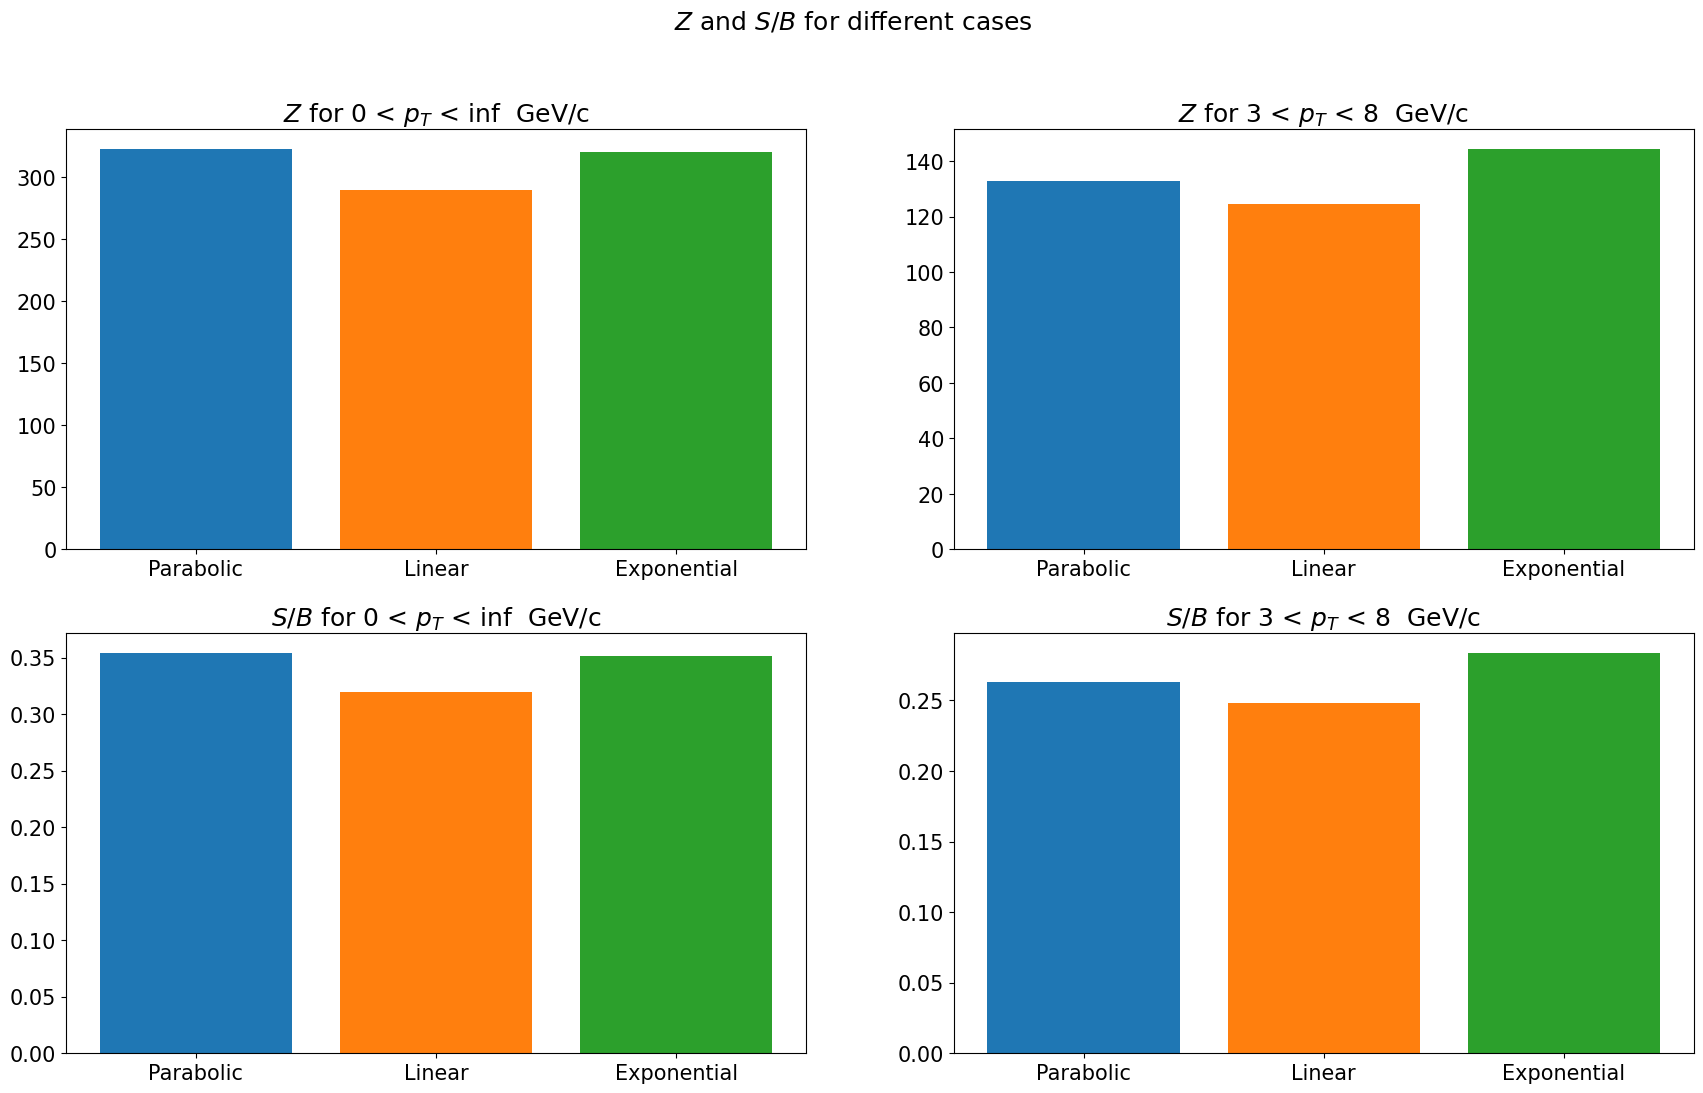

In [10]:
fig, axs = plt.subplots( nrows = 2, ncols = times, figsize = ( 21, 12 ) )
fig.suptitle(f"$Z$ and $S/B$ for different cases")
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# BARPLOT
axs[0][0].bar(["Parabolic", "Linear", "Exponential"], recap["StatSignif"].iloc[:3], color=colors)
axs[0][1].bar(["Parabolic", "Linear", "Exponential"], recap["StatSignif"].iloc[3:], color=colors)
axs[1][0].bar(["Parabolic", "Linear", "Exponential"], recap["S/B"].iloc[:3], color=colors)
axs[1][1].bar(["Parabolic", "Linear", "Exponential"], recap["S/B"].iloc[3:], color=colors)

# ESTETICHS
axs[0][0].set_title(f"$Z$ for {pt_extremes[0][0]} < $p_T$ < {pt_extremes[0][1]}  GeV/c" )
axs[0][1].set_title(f"$Z$ for {pt_extremes[1][0]} < $p_T$ < {pt_extremes[1][1]}  GeV/c" )
axs[1][0].set_title(f"$S/B$ for {pt_extremes[0][0]} < $p_T$ < {pt_extremes[0][1]}  GeV/c" )
axs[1][1].set_title(f"$S/B$ for {pt_extremes[1][0]} < $p_T$ < {pt_extremes[1][1]}  GeV/c" )
plt.show()